### Mashiur Rahman 

## Assignment 11: Image Classification Using Random Forest

## 1. Dataset Selection and Preprocessing

In [1]:
!pip install scikit-image --quiet


[notice] A new release of pip is available: 24.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
import skimage.io
from skimage.transform import resize
from sklearn.utils import Bunch
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

from skimage.io import imread
from skimage.transform import resize
import skimage.io

In [3]:
# Path to the main folder containing all five categories
image_folder = r"C:\Users\Mashiur\Downloads\images\images"

# Check the dataset location
print("Path exists:", os.path.exists(image_folder))
print("Categories:", sorted(os.listdir(image_folder)))

Path exists: True
Categories: ['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']


### Load Images from the Structured Directory

In [4]:
def load_image_files(container_path, dimension=(64, 64)):
    """
    Load image files with categories as subfolder names.
    The output is structured like a scikit-learn sample dataset.
    """

    image_dir = Path(container_path)

    # Find all category folders
    folders = sorted([
        directory
        for directory in image_dir.iterdir()
        if directory.is_dir()
    ])

    categories = [folder.name for folder in folders]

    descr = "Image classification dataset"

    images = []
    flat_data = []
    target = []

    valid_extensions = [".jpg", ".jpeg", ".png"]

    for category_number, folder in enumerate(folders):

        for file in folder.iterdir():

            if file.suffix.lower() in valid_extensions:

                try:
                    # Read the image
                    img = skimage.io.imread(file)

                    # Remove transparency channel if present
                    if img.ndim == 3 and img.shape[2] == 4:
                        img = img[:, :, :3]

                    # Convert grayscale images to RGB
                    if img.ndim == 2:
                        img = np.stack(
                            [img, img, img],
                            axis=-1
                        )

                    # Resize the image
                    img_resized = resize(
                        img,
                        dimension,
                        anti_aliasing=True,
                        mode="reflect"
                    )

                    # Flatten the resized image
                    flat_data.append(
                        img_resized.flatten()
                    )

                    images.append(img_resized)
                    target.append(category_number)

                except Exception as error:
                    print("Could not load:", file)
                    print(error)

    flat_data = np.array(flat_data)
    target = np.array(target)
    images = np.array(images)

    return Bunch(
        data=flat_data,
        target=target,
        target_names=categories,
        images=images,
        DESCR=descr
    )

In [5]:
# Load and preprocess all images
image_dataset = load_image_files(image_folder)

print("Total images:", len(image_dataset.images))
print("Image shape:", image_dataset.images[0].shape)
print("Data shape:", image_dataset.data.shape)
print("Categories:", image_dataset.target_names)

Total images: 309
Image shape: (64, 64, 3)
Data shape: (309, 12288)
Categories: ['dalmatian', 'dollar_bill', 'pizza', 'soccer_ball', 'sunflower']


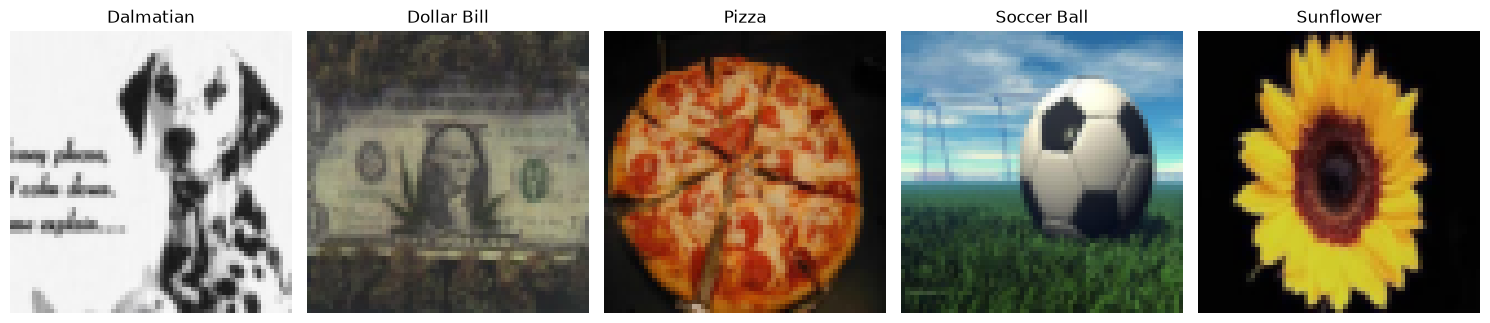

In [6]:
# Display one image from each category
plt.figure(figsize=(15, 4))

for category_number, category_name in enumerate(
    image_dataset.target_names
):
    image_index = np.where(
        image_dataset.target == category_number
    )[0][0]

    plt.subplot(
        1,
        len(image_dataset.target_names),
        category_number + 1
    )

    plt.imshow(image_dataset.images[image_index])

    plt.title(
        category_name.replace("_", " ").title()
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
# Display the number of images in each category
for category_number, category_name in enumerate(
    image_dataset.target_names
):
    image_count = np.sum(
        image_dataset.target == category_number
    )

    print(category_name, ":", image_count)

dalmatian : 67
dollar_bill : 51
pizza : 52
soccer_ball : 54
sunflower : 85


In [8]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    image_dataset.data,
    image_dataset.target,
    test_size=0.30,
    random_state=109,
    stratify=image_dataset.target
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (216, 12288)
Testing data shape: (93, 12288)


## 2. Model Training

In [9]:
# Define the Random Forest parameter grid
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Create the Random Forest classifier
random_forest = RandomForestClassifier(
    random_state=42
)

# Create the GridSearchCV object
clf = GridSearchCV(
    random_forest,
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

# Train the models and find the best parameters
clf.fit(X_train, y_train)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_

In [10]:
# Print the best parameters
print("Best Parameters:")
print(clf.best_params_)

print("\nBest Cross-Validation Accuracy:")
print(round(clf.best_score_, 4))

# Get the best Random Forest model
best_model = clf.best_estimator_

print("\nBest Model:")
print(best_model)

Best Parameters:
{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Best Cross-Validation Accuracy:
0.7639

Best Model:
RandomForestClassifier(min_samples_leaf=2, min_samples_split=5, random_state=42)


## 3. Model Evaluation

In [11]:
# Predict categories for the testing data
y_pred = clf.predict(X_test)

print("Prediction completed.")

Prediction completed.


In [12]:
# Calculate accuracy, precision, recall and F1-score
accuracy = metrics.accuracy_score(
    y_test,
    y_pred
)

precision = metrics.precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = metrics.recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = metrics.f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.7634
Precision: 0.7690
Recall:    0.7634
F1-score:  0.7634


In [13]:
# Print the classification report
print("Classification Report:\n")

print(
    metrics.classification_report(
        y_test,
        y_pred,
        target_names=image_dataset.target_names,
        zero_division=0
    )
)

Classification Report:

              precision    recall  f1-score   support

   dalmatian       0.88      0.70      0.78        20
 dollar_bill       0.87      0.87      0.87        15
       pizza       0.62      0.62      0.62        16
 soccer_ball       0.71      0.75      0.73        16
   sunflower       0.76      0.85      0.80        26

    accuracy                           0.76        93
   macro avg       0.77      0.76      0.76        93
weighted avg       0.77      0.76      0.76        93



In [14]:
# Create the confusion matrix
confusion_matrix_result = metrics.confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(confusion_matrix_result)

Confusion Matrix:
[[14  1  0  5  0]
 [ 0 13  2  0  0]
 [ 0  0 10  0  6]
 [ 2  1  0 12  1]
 [ 0  0  4  0 22]]


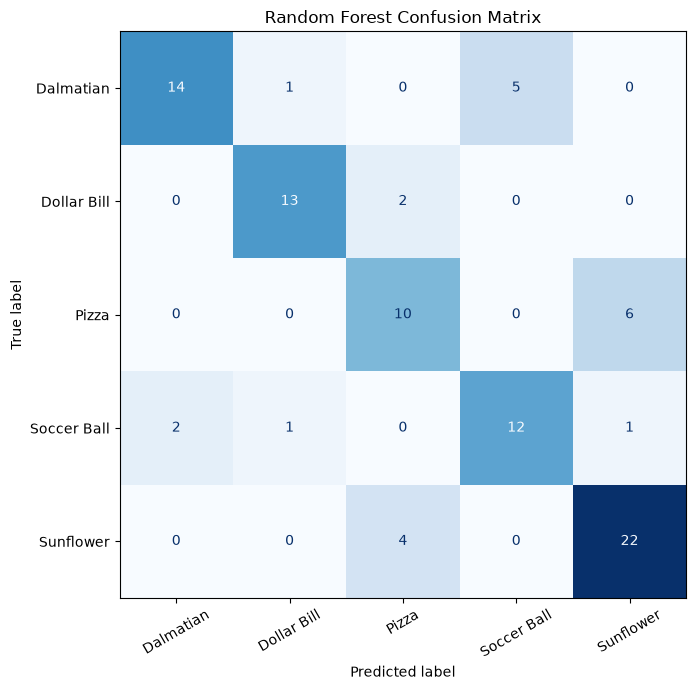

In [15]:
# Visualize the confusion matrix
display_names = [
    name.replace("_", " ").title()
    for name in image_dataset.target_names
]

display = metrics.ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_result,
    display_labels=display_names
)

fig, ax = plt.subplots(figsize=(9, 7))

display.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False
)

plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Feature Importance Visualization

In [16]:
# Get feature importance values from the best model
feature_importances = best_model.feature_importances_

# Find the 20 most important features
top_feature_indices = np.argsort(
    feature_importances
)[-20:]

top_importance_values = feature_importances[
    top_feature_indices
]

print("Total number of features:",
      len(feature_importances))

print("Top 20 feature indices:")
print(top_feature_indices)

Total number of features: 12288
Top 20 feature indices:
[4337 5285 5696 4700 4121 4112 4685 5825 4742 3929 4493 4865 4346 6407
 5060 6794 4298 6437 4310 4343]


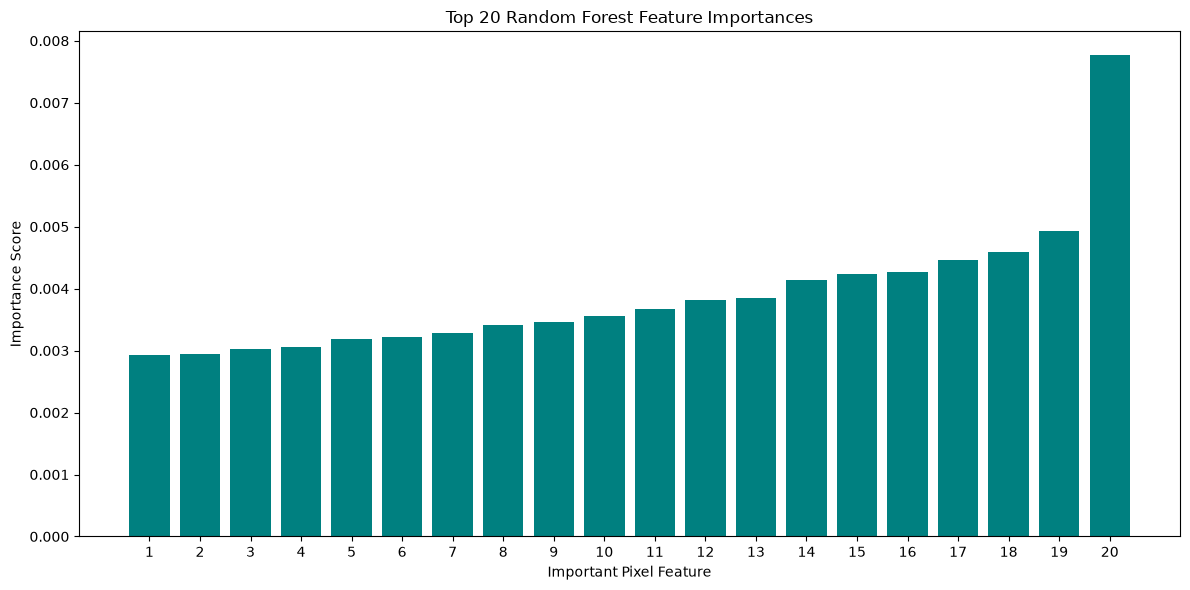

In [17]:
# Create a bar plot of the 20 most important features
plt.figure(figsize=(12, 6))

plt.bar(
    range(1, 21),
    top_importance_values,
    color="teal"
)

plt.xlabel("Important Pixel Feature")
plt.ylabel("Importance Score")
plt.title("Top 20 Random Forest Feature Importances")
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()

## 5. Prediction on New Images

In [18]:
def predict_new_image(sample_image_path):
    """
    Read, resize and classify one new image.
    """

    try:
        # Read the new image
        img = skimage.io.imread(sample_image_path)

        # Remove transparency channel if present
        if img.ndim == 3 and img.shape[2] == 4:
            img = img[:, :, :3]

        # Convert grayscale image to RGB
        if img.ndim == 2:
            img = np.stack(
                [img, img, img],
                axis=-1
            )

        # Resize using the same training dimensions
        img_resized = resize(
            img,
            (64, 64),
            anti_aliasing=True,
            mode="reflect"
        )

        # Flatten the resized image
        flattened_image = np.array([
            img_resized.flatten()
        ])

        # Predict the category
        predicted_index = clf.predict(
            flattened_image
        )[0]

        # Convert the number to a category name
        predicted_category = (
            image_dataset
            .target_names[predicted_index]
        )

        # Display the image and prediction
        plt.figure(figsize=(5, 5))
        plt.imshow(img)

        plt.title(
            "Prediction: " +
            predicted_category.upper(),
            fontsize=14,
            color="green",
            fontweight="bold"
        )

        plt.axis("off")
        plt.show()

        print(
            "Predicted category:",
            predicted_category
        )

        return predicted_category

    except FileNotFoundError:
        print(
            "Error: Could not find the image at:",
            sample_image_path
        )

    except Exception as error:
        print("An error occurred:", error)

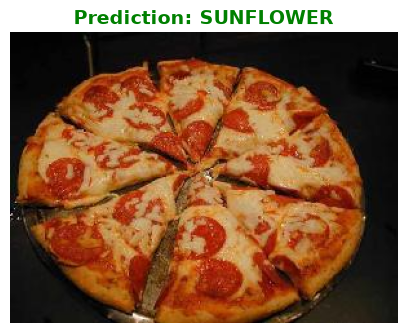

Predicted category: sunflower


'sunflower'

In [19]:
# Test the model using one existing pizza image
sample_image_path = (
    r"C:\Users\Mashiur\Downloads\images\images"
    r"\pizza\image_0001.jpg"
)

predict_new_image(sample_image_path)

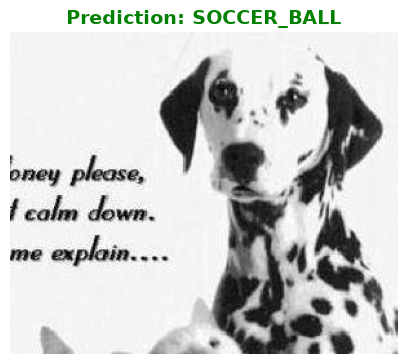

Predicted category: soccer_ball


'soccer_ball'

In [20]:
sample_image_path = (
    r"C:\Users\Mashiur\Downloads\images\images"
    r"\dalmatian\image_0001.jpg"
)

predict_new_image(sample_image_path)

## 7. Conclusion

This project developed an image-classification model using five categories: Dalmatian, dollar bill, pizza, soccer ball, and sunflower. All images were loaded from structured folders, resized to 64 × 64 pixels, normalized, flattened, and divided into training and testing sets. A Random Forest classifier was trained, and GriSdearchCV was used to identify the best model parameters.

The model was evaluated using accuracy, precision, recall, F1-score, a classification report, and a confusion matrix. Feature importance was also visualized to identify the pixels that contributed most to the predictions. During new-image testing, a Dalmatian image was incorrectly classified as a soccer ball, possibly because both contain similar black-and-white patterns. This shows that the model performs classification successfully but may confuse visually similar categories. For deployment, the trained model could be saved and integrated into a simple application where users upload an image and receive its predicted category.